# GA4 Funnel Conversion Analysis

This notebook looks at how users move through the e-commerce funnel:

view_item → add_to_cart → begin_checkout → purchase

The analysis focuses on where users leave the funnel and whether checkout conversion differs between mobile and desktop users.
I will calculate conversion and drop-off rates, test whether the device difference is statistically significant, and estimate the
sample size required for a future A/B test.
The data comes from Google’s public GA4 e-commerce sample, which was stored and transformed using BigQuery and dbt.
This is an observational analysis, not a live A/B test. Therefore, any differences between mobile and desktop users 
should be treated as associations rather than proof that the device itself caused the result.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Set a consistent chart style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the BigQuery results

funnel_df = pd.read_csv("../../data/sample/ga4_funnel_summary.csv")
device_df = pd.read_csv("../../data/sample/ga4_device_checkout_conversion.csv")

print("Funnel data:")
display(funnel_df)

print("Device conversion data:")
display(device_df)

Funnel data:


,stage_order,funnel_stage,users
0,1,view_item,61252
1,2,add_to_cart,12545
2,3,begin_checkout,9715
3,4,purchase,4419


Device conversion data:


,device_category,checkout_users,purchasers,conversion_rate
0,desktop,5606,2520,0.4495
1,mobile,3892,1797,0.4617
2,tablet,217,101,0.4654


In [4]:
# Calculate conversion and drop-off at each funnel stage
funnel_analysis = funnel_df.sort_values("stage_order").copy()

funnel_analysis["previous_stage_users"] = funnel_analysis["users"].shift(1)
funnel_analysis["users_lost"] = (
    funnel_analysis["previous_stage_users"] - funnel_analysis["users"]
).fillna(0).astype(int)

funnel_analysis["stage_conversion_rate"] = (
    funnel_analysis["users"] / funnel_analysis["previous_stage_users"]
)

# The first stage is the starting point
funnel_analysis.loc[
    funnel_analysis.index[0], "stage_conversion_rate"
] = 1

funnel_analysis["drop_off_rate"] = (
    1 - funnel_analysis["stage_conversion_rate"]
)

funnel_analysis["overall_conversion_rate"] = (
    funnel_analysis["users"] / funnel_analysis["users"].iloc[0]
)

# Display percentages in an easier-to-read format
funnel_analysis["stage_conversion_pct"] = (
    funnel_analysis["stage_conversion_rate"] * 100
).round(2)

funnel_analysis["drop_off_pct"] = (
    funnel_analysis["drop_off_rate"] * 100
).round(2)

funnel_analysis["overall_conversion_pct"] = (
    funnel_analysis["overall_conversion_rate"] * 100
).round(2)

display(
    funnel_analysis[
        [
            "funnel_stage",
            "users",
            "users_lost",
            "stage_conversion_pct",
            "drop_off_pct",
            "overall_conversion_pct"
        ]
    ]
)

,funnel_stage,users,users_lost,stage_conversion_pct,drop_off_pct,overall_conversion_pct
0,view_item,61252,0,100.00,0.00,100.00
1,add_to_cart,12545,48707,20.48,79.52,20.48
2,begin_checkout,9715,2830,77.44,22.56,15.86
3,purchase,4419,5296,45.49,54.51,7.21


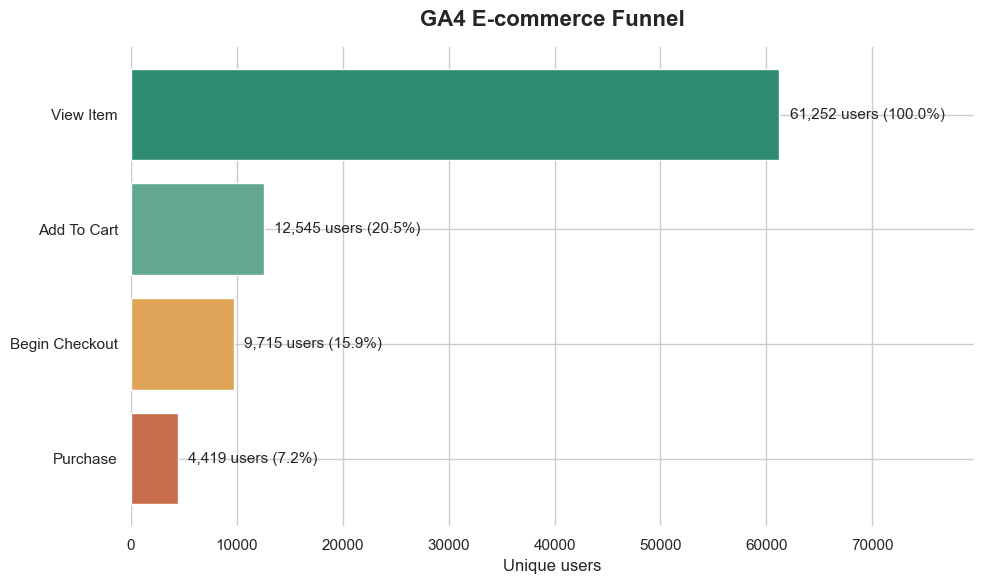

In [5]:
# Create readable labels for the chart
chart_data = funnel_analysis.copy()
chart_data["stage_label"] = (
    chart_data["funnel_stage"]
    .str.replace("_", " ")
    .str.title()
)

colors = ["#2E8B70", "#62A78F", "#E0A458", "#C76D4B"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    chart_data["stage_label"],
    chart_data["users"],
    color=colors
)

ax.invert_yaxis()

# Add user counts and overall conversion percentages
for bar, users, percentage in zip(
    bars,
    chart_data["users"],
    chart_data["overall_conversion_pct"]
):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{users:,} users ({percentage:.1f}%)",
        va="center",
        fontsize=11
    )

ax.set_title(
    "GA4 E-commerce Funnel",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Unique users")
ax.set_ylabel("")
ax.set_xlim(0, chart_data["users"].max() * 1.3)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    "ga4_funnel_conversion_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Select the two device groups for statistical comparison
mobile = device_df.loc[
    device_df["device_category"] == "mobile"
].iloc[0]

desktop = device_df.loc[
    device_df["device_category"] == "desktop"
].iloc[0]

successes = np.array([
    mobile["purchasers"],
    desktop["purchasers"]
])

sample_sizes = np.array([
    mobile["checkout_users"],
    desktop["checkout_users"]
])

# Two-proportion z-test
z_statistic, p_value = proportions_ztest(
    successes,
    sample_sizes
)

mobile_rate = mobile["purchasers"] / mobile["checkout_users"]
desktop_rate = desktop["purchasers"] / desktop["checkout_users"]
rate_difference = mobile_rate - desktop_rate

# 95% confidence interval for the difference
standard_error = np.sqrt(
    (mobile_rate * (1 - mobile_rate) / mobile["checkout_users"])
    +
    (desktop_rate * (1 - desktop_rate) / desktop["checkout_users"])
)

critical_value = stats.norm.ppf(0.975)

ci_lower = rate_difference - critical_value * standard_error
ci_upper = rate_difference + critical_value * standard_error

test_result = pd.DataFrame({
    "Metric": [
        "Mobile conversion rate",
        "Desktop conversion rate",
        "Difference (mobile - desktop)",
        "Z-statistic",
        "P-value",
        "95% CI lower",
        "95% CI upper",
        "Statistically significant"
    ],
    "Result": [
        f"{mobile_rate:.2%}",
        f"{desktop_rate:.2%}",
        f"{rate_difference:.2%}",
        f"{z_statistic:.3f}",
        f"{p_value:.4f}",
        f"{ci_lower:.2%}",
        f"{ci_upper:.2%}",
        "Yes" if p_value < 0.05 else "No"
    ]
})

display(test_result)

,Metric,Result
0,Mobile conversion rate,46.17%
1,Desktop conversion rate,44.95%
2,Difference (mobile - desktop),1.22%
3,Z-statistic,1.174
4,P-value,0.2403
5,95% CI lower,-0.82%
6,95% CI upper,3.26%
7,Statistically significant,No


### Device conversion result

Mobile users had a checkout conversion rate of 46.17%, compared with 44.95% for desktop users. This is a difference of 1.22 percentage points.

However, the difference was not statistically significant (p = 0.2403). The 95% confidence interval ranged from -0.82 to 3.26 percentage points and included zero. Based on this dataset, there is not enough evidence to conclude that mobile users convert differently from desktop users.

The result should not be used to recommend a device-specific checkout change on its own. Other factors, such as traffic source, customer intent and product mix, may also influence conversion.

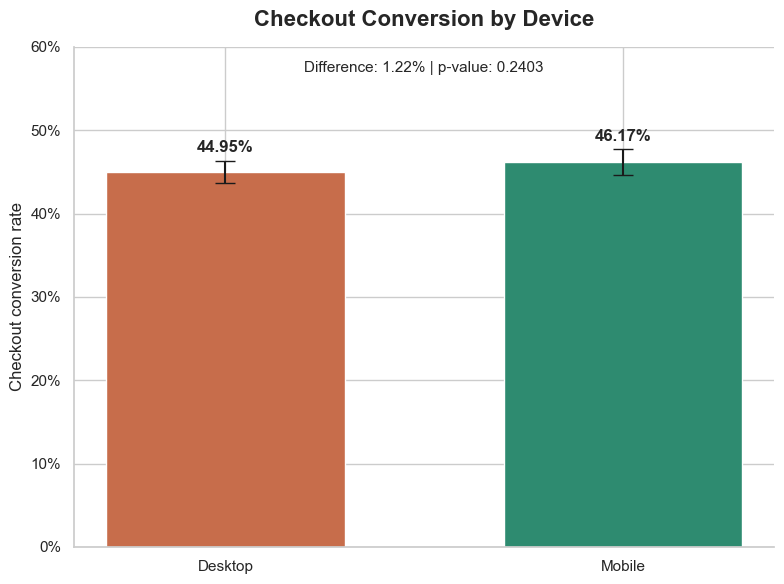

In [8]:
from matplotlib.ticker import PercentFormatter

# Prepare desktop and mobile results
device_chart = device_df[
    device_df["device_category"].isin(["desktop", "mobile"])
].copy()

device_chart["conversion_rate_exact"] = (
    device_chart["purchasers"] / device_chart["checkout_users"]
)

device_chart["ci_margin"] = critical_value * np.sqrt(
    device_chart["conversion_rate_exact"]
    * (1 - device_chart["conversion_rate_exact"])
    / device_chart["checkout_users"]
)

device_chart["device_label"] = (
    device_chart["device_category"].str.title()
)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    device_chart["device_label"],
    device_chart["conversion_rate_exact"],
    yerr=device_chart["ci_margin"],
    capsize=7,
    color=["#C76D4B", "#2E8B70"],
    width=0.6
)

for bar, rate in zip(
    bars,
    device_chart["conversion_rate_exact"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{rate:.2%}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.text(
    0.5,
    0.95,
    f"Difference: {rate_difference:.2%} | p-value: {p_value:.4f}",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_title(
    "Checkout Conversion by Device",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("Checkout conversion rate")
ax.set_xlabel("")
ax.set_ylim(0, 0.60)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

sns.despine()
plt.tight_layout()

plt.savefig(
    "ga4_device_conversion_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The largest loss occurred between product viewing and adding an item to the cart. Of 61,252 users who viewed a product, only 12,545 added an item to their cart, representing a 79.52% drop. This suggests that product relevance, pricing, product-page content or customer intent should be investigated first.

A second important drop occurred during checkout. Of 9,715 users who began checkout, 4,419 completed a purchase. The overall purchase rate was 7.21% of product viewers.

Mobile checkout conversion was 46.17%, compared with 44.95% for desktop. Although mobile conversion was 1.22 percentage points higher, the difference was not statistically significant. There is therefore no strong evidence for prioritising a device-specific checkout change.

The business should first investigate product-to-cart behaviour and checkout abandonment by traffic source and product category. The analysis uses an open funnel from an anonymised public dataset, so it identifies patterns but does not prove what caused them.

In [10]:
funnel_analysis.to_csv(
    "ga4_funnel_analysis_results.csv",
    index=False
)

test_result.to_csv(
    "ga4_device_statistical_test_results.csv",
    index=False
)

print("Analysis results exported successfully.")

Analysis results exported successfully.
